In [ ]:
import pathlib

In [ ]:
import marimo as mo
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-05-22T21:50:16.333397+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1052-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

requests  : 2.34.2
matplotlib: 3.9.2
pandas    : 2.2.3
numpy     : 2.1.2
seaborn   : 0.13.2
marimo    : 0.23.2
teeplot   : 1.4.2

```

## Prep Data

In [ ]:
with open("/tmp/aum7w", "wb") as fp:
    fp.write(
        requests.get(
            "https://osf.io/download/aum7w", allow_redirects=True
        ).content,
    )

In [ ]:
data = pd.read_csv("/tmp/aum7w", compression="gzip")
data

,././@LongLink,proc,Impl Filter,Num Outlets,Num Reads Performed,Num Reads That Were Fresh,Num Reads That Were Stale,Num Revisions Pulled,Net Flux Through Duct,Num Try Pulls Attempted,...,Async Mode,Num Threads,Num Simulation Elements Per Cpu,Num Processes,Execution Instance UUID,Process Instance UUID,SLURM_NNODES,SLURM_NTASKS,SLURM_CPUS_ON_NODE,Source File
0,1.245552e+15,1.0,proc,1.0,8262.0,2681.0,5581.0,2681.0,2938.0,2754.0,...,3.0,1.0,1.0,2.0,ffcf502e-c955-48b5-9948-fe7554603225,09a530f8-0432-47e7-aee9-c6e37f653ea9,1.0,2.0,2.0,a=conduit_instrumentation+async_mode=3+impl=proc+nproc=2+nthread=1+proc=1+replicate=0+slurm_nnodes=1+slurm_ntasks=2+subject=outlet+view=summary+_hostname=lac-361+_revision=05e56114-clean+ext=.csv
1,1.245553e+15,1.0,proc,1.0,232761.0,77426.0,155335.0,77426.0,80932.0,77587.0,...,3.0,1.0,1.0,2.0,ffcf502e-c955-48b5-9948-fe7554603225,09a530f8-0432-47e7-aee9-c6e37f653ea9,1.0,2.0,2.0,a=conduit_instrumentation+async_mode=3+impl=proc+nproc=2+nthread=1+proc=1+replicate=0+slurm_nnodes=1+slurm_ntasks=2+subject=outlet+view=summary+_hostname=lac-361+_revision=05e56114-clean+ext=.csv
2,1.245612e+15,1.0,proc,1.0,29497767.0,9826109.0,19671658.0,9826109.0,13058938.0,9832589.0,...,3.0,1.0,1.0,2.0,ffcf502e-c955-48b5-9948-fe7554603225,09a530f8-0432-47e7-aee9-c6e37f653ea9,1.0,2.0,2.0,a=conduit_instrumentation+async_mode=3+impl=proc+nproc=2+nthread=1+proc=1+replicate=0+slurm_nnodes=1+slurm_ntasks=2+subject=outlet+view=summary+_hostname=lac-361+_revision=05e56114-clean+ext=.csv
3,1.245613e+15,1.0,proc,1.0,29719380.0,9899844.0,19819536.0,9899844.0,13136125.0,9906460.0,...,3.0,1.0,1.0,2.0,ffcf502e-c955-48b5-9948-fe7554603225,09a530f8-0432-47e7-aee9-c6e37f653ea9,1.0,2.0,2.0,a=conduit_instrumentation+async_mode=3+impl=proc+nproc=2+nthread=1+proc=1+replicate=0+slurm_nnodes=1+slurm_ntasks=2+subject=outlet+view=summary+_hostname=lac-361+_revision=05e56114-clean+ext=.csv
4,1.245672e+15,1.0,proc,1.0,58475955.0,19478941.0,38997014.0,19478941.0,25936934.0,19491986.0,...,3.0,1.0,1.0,2.0,ffcf502e-c955-48b5-9948-fe7554603225,09a530f8-0432-47e7-aee9-c6e37f653ea9,1.0,2.0,2.0,a=conduit_instrumentation+async_mode=3+impl=proc+nproc=2+nthread=1+proc=1+replicate=0+slurm_nnodes=1+slurm_ntasks=2+subject=outlet+view=summary+_hostname=lac-361+_revision=05e56114-clean+ext=.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
516,1.232516e+15,1.0,proc,1.0,78405315.0,2533935.0,75871380.0,2533935.0,29727629.0,26135105.0,...,3.0,1.0,1.0,2.0,bf81faa0-5108-4e0e-ab07-8e8794ccca18,cb18e7e6-a24f-41a7-8ad1-8597eaa2782e,2.0,2.0,1.0,a=conduit_instrumentation+async_mode=3+impl=proc+nproc=2+nthread=1+proc=1+replicate=0+slurm_nnodes=2+slurm_ntasks=2+subject=outlet+view=summary+_hostname=lac-221+_revision=05e56114-clean+ext=.csv
517,1.232575e+15,1.0,proc,1.0,97908018.0,3161966.0,94746052.0,3161966.0,37073542.0,32636006.0,...,3.0,1.0,1.0,2.0,bf81faa0-5108-4e0e-ab07-8e8794ccca18,cb18e7e6-a24f-41a7-8ad1-8597eaa2782e,2.0,2.0,1.0,a=conduit_instrumentation+async_mode=3+impl=proc+nproc=2+nthread=1+proc=1+replicate=0+slurm_nnodes=2+slurm_ntasks=2+subject=outlet+view=summary+_hostname=lac-221+_revision=05e56114-clean+ext=.csv
518,1.232576e+15,1.0,proc,1.0,98103951.0,3165718.0,94938233.0,3165718.0,37143741.0,32701317.0,...,3.0,1.0,1.0,2.0,bf81faa0-5108-4e0e-ab07-8e8794ccca18,cb18e7e6-a24f-41a7-8ad1-8597eaa2782e,2.0,2.0,1.0,a=conduit_instrumentation+async_mode=3+impl=proc+nproc=2+nthread=1+proc=1+replicate=0+slurm_nnodes=2+slurm_ntasks=2+subject=outlet+view=summary+_hostname=lac-221+_revision=05e56114-clean+ext=.csv
519,1.232604e+15,1.0,proc,1.0,107456203.0,3467919.0,103988284.0,3467919.0,40685969.0,35818735.0,...,3.0,1.0,1.0,2.0,bf81faa0-5108-4e0e-ab07-8e8794ccca18,cb18e7e6-a24f-41a7-8ad1-8597eaa2782e,2.0,2.0,1.0,a=conduit_instrumentation+async_mode=3+impl=proc+nproc=2+nthread=1+proc=1+replicate=0+slurm_nnodes=2+slurm_ntasks=2+subject=outlet+view=summary+_hostname=lac-221+_revision=05e56114-clean+ext=.csv


In [ ]:
group_cols = ["SLURM_NNODES", "Replicate", "proc"]
value_cols = ["Num Pulls Attempted", "Row Final Timepoint (ns)"]

diffs = data.groupby(group_cols)[value_cols].diff().add_suffix(" Diff")

result = pd.concat(
    [data[[*group_cols, "Row Final Timepoint (ns)"]], diffs], axis=1
)

result["Row Final Timepoint (ns) Rel"] = result[
    "Row Final Timepoint (ns)"
] - result.groupby(group_cols)["Row Final Timepoint (ns)"].transform("min")

result["Updates per Sec"] = (
    result["Num Pulls Attempted Diff"]
    / result["Row Final Timepoint (ns) Diff"]
    * 10**9
)

result["rank"] = result.groupby(group_cols)[
    "Row Final Timepoint (ns)"
].transform("rank")

result

,SLURM_NNODES,Replicate,proc,Row Final Timepoint (ns),Num Pulls Attempted Diff,Row Final Timepoint (ns) Diff,Row Final Timepoint (ns) Rel,Updates per Sec,rank
0,1.0,0.0,1.0,1.245552e+15,NaN,NaN,0.000000e+00,NaN,1.0
1,1.0,0.0,1.0,1.245553e+15,74833.0,1.002366e+09,1.002366e+09,74656.394923,2.0
2,1.0,0.0,1.0,1.245612e+15,9755002.0,5.900502e+10,6.000738e+10,165324.956955,3.0
3,1.0,0.0,1.0,1.245613e+15,73871.0,1.002276e+09,6.100966e+10,73703.247208,4.0
4,1.0,0.0,1.0,1.245672e+15,9585526.0,5.899306e+10,1.200027e+11,162485.659268,5.0
...,...,...,...,...,...,...,...,...,...
516,2.0,0.0,1.0,1.232516e+15,65924.0,1.015337e+09,2.410177e+11,64928.202457,10.0
517,2.0,0.0,1.0,1.232575e+15,6500901.0,5.898507e+10,3.000028e+11,110212.657074,11.0
518,2.0,0.0,1.0,1.232576e+15,65311.0,1.015428e+09,3.010182e+11,64318.683377,12.0
519,2.0,0.0,1.0,1.232604e+15,3117418.0,2.840054e+10,3.294188e+11,109766.170638,13.0


teeplots/2026-05-15-mp-vs-mt-beleagurement-ts/hue=special+kind=line+row=special+viz=relplot+x=rank3+y=updates-per-sec+ext=.pdf
teeplots/2026-05-15-mp-vs-mt-beleagurement-ts/hue=special+kind=line+row=special+viz=relplot+x=rank3+y=updates-per-sec+ext=.png


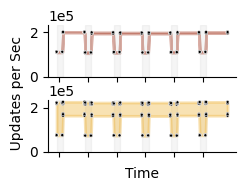

In [ ]:
newdf = pd.DataFrame(np.repeat(result.values, 2, axis=0))
newdf.columns = result.columns

newdf["rank2"] = newdf.groupby(group_cols).cumcount() - 2

newdf["special"] = newdf["Replicate"].isin([1, 4, 6, 9])

newdf["rank3"] = newdf["rank2"].replace(
    {i: (i // 4) * 40 + [0, 8, 9, 39][i % 4] for i in range(25)}
)

newdf["rp"] = newdf["Replicate"].astype(str) + newdf["proc"].astype(str)

with tp.teed(
    sns.relplot,
    data=newdf[newdf["SLURM_NNODES"] == 1],
    x="rank3",
    y="Updates per Sec",
    row="special",
    hue="special",
    row_order=[True, False],
    errorbar=("pi", 100),
    kind="line",
    # estimator=None,
    sort=True,
    legend=False,
    err_kws=dict(alpha=0.4, lw=2),
    lw=0,
    palette=["#EFB743", "#A1331C"],
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _g.set(ylim=(0, None))
    _g.figure.set_size_inches(3, 2)
    _g.set_titles("")

    _g.map_dataframe(
        sns.scatterplot,
        x="rank3",
        y="Updates per Sec",
        # hue="special",
        # dashes=[(1, 0)],
        marker=".",
        size=0.1,
        # linewidth=0.3,
        legend=None,
        # estimator=None,
        # style="proc",
        color="black",
        # sort=True,
    )

    for _ax in _g.axes.flat:
        for i in (0, 40, 80, 120, 160, 200):
            _ax.axvspan(
                0 + i, 8.5 + i, color="gray", alpha=0.08, zorder=-1
            )

    plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    _g.axes.flat[0].set_ylabel("")
    _g.axes.flat[1].set_ylabel("               Updates per Sec")

    _g.set(
        xlabel="Time", xticklabels=[], xticks=[4, 44, 84, 124, 164, 204]
    )

teeplots/2026-05-15-mp-vs-mt-beleagurement-ts/hue=special+kind=line+row=special+viz=relplot+x=rank3+y=secs-per-update+ext=.pdf
teeplots/2026-05-15-mp-vs-mt-beleagurement-ts/hue=special+kind=line+row=special+viz=relplot+x=rank3+y=secs-per-update+ext=.png


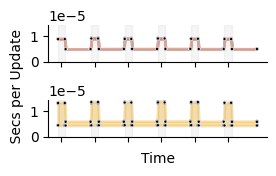

In [ ]:
newdf2 = pd.DataFrame(np.repeat(result.values, 2, axis=0))
newdf2.columns = result.columns

newdf2["rank2"] = newdf2.groupby(group_cols).cumcount() - 2

newdf2["special"] = newdf2["Replicate"].isin([1, 4, 6, 9])

newdf2["rank3"] = newdf2["rank2"].replace(
    {i: (i // 4) * 40 + [0, 8, 9, 39][i % 4] for i in range(25)}
)

newdf2["rp"] = newdf2["Replicate"].astype(str) + newdf2["proc"].astype(str)

newdf2["Secs per Update"] = 1.0 / newdf2["Updates per Sec"]

with tp.teed(
    sns.relplot,
    data=newdf2[newdf2["SLURM_NNODES"] == 1],
    x="rank3",
    y="Secs per Update",
    row="special",
    hue="special",
    row_order=[True, False],
    errorbar=("pi", 100),
    kind="line",
    # estimator=None,
    sort=True,
    legend=False,
    err_kws=dict(alpha=0.4, lw=2),
    lw=0,
    palette=["#EFB743", "#A1331C"],
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _g.set(ylim=(0, None))
    _g.figure.set_size_inches(3, 2)
    _g.set_titles("")

    _g.map_dataframe(
        sns.scatterplot,
        x="rank3",
        y="Secs per Update",
        marker=".",
        size=0.1,
        legend=None,
        color="black",
    )

    for _ax in _g.axes.flat:
        for _i in (0, 40, 80, 120, 160, 200):
            _ax.axvspan(
                0 + _i, 8.5 + _i, color="gray", alpha=0.08, zorder=-1
            )

    plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    _g.axes.flat[0].set_ylabel("")
    _g.axes.flat[1].set_ylabel("               Secs per Update")

    _g.set(
        xlabel="Time", xticklabels=[], xticks=[4, 44, 84, 124, 164, 204]
    )

teeplots/2026-05-15-mp-vs-mt-beleagurement-ts/hue=special+kind=line+row=special+viz=relplot+x=rank3+y=ms-per-update+ext=.pdf
teeplots/2026-05-15-mp-vs-mt-beleagurement-ts/hue=special+kind=line+row=special+viz=relplot+x=rank3+y=ms-per-update+ext=.png


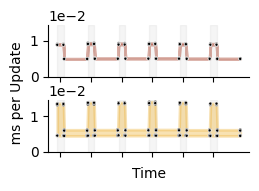

In [ ]:
newdf3 = pd.DataFrame(np.repeat(result.values, 2, axis=0))
newdf3.columns = result.columns

newdf3["rank2"] = newdf3.groupby(group_cols).cumcount() - 2

newdf3["special"] = newdf3["Replicate"].isin([1, 4, 6, 9])

newdf3["rank3"] = newdf3["rank2"].replace(
    {i: (i // 4) * 40 + [0, 8, 9, 39][i % 4] for i in range(25)}
)

newdf3["rp"] = newdf3["Replicate"].astype(str) + newdf3["proc"].astype(str)

newdf3["ms per Update"] = 1000.0 / newdf3["Updates per Sec"]

with tp.teed(
    sns.relplot,
    data=newdf3[newdf3["SLURM_NNODES"] == 1],
    x="rank3",
    y="ms per Update",
    row="special",
    hue="special",
    row_order=[True, False],
    errorbar=("pi", 100),
    kind="line",
    # estimator=None,
    sort=True,
    legend=False,
    err_kws=dict(alpha=0.4, lw=2),
    lw=0,
    palette=["#EFB743", "#A1331C"],
    teeplot_show=True,
    teeplot_subdir=pathlib.Path(__file__).stem,
) as _g:
    _g.set(ylim=(0, None))
    _g.figure.set_size_inches(3, 2)
    _g.set_titles("")

    _g.map_dataframe(
        sns.scatterplot,
        x="rank3",
        y="ms per Update",
        marker=".",
        size=0.1,
        legend=None,
        color="black",
    )

    for _ax in _g.axes.flat:
        for _i in (0, 40, 80, 120, 160, 200):
            _ax.axvspan(
                0 + _i, 8.5 + _i, color="gray", alpha=0.08, zorder=-1
            )

    plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    _g.axes.flat[0].set_ylabel("")
    _g.axes.flat[1].set_ylabel("               ms per Update")

    _g.set(
        xlabel="Time", xticklabels=[], xticks=[4, 44, 84, 124, 164, 204]
    )